## Cell 1 : Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Setup estetika visualisasi (Ukuran default, resolusi, dan warna)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("Library berhasil dimuat dan visualisasi sudah disetel!")

Library berhasil dimuat dan visualisasi sudah disetel!


## Cell 2 : Koneksi dan Tarik Data 

In [3]:
# Pastikan path ini sesuai dengan posisi .env milikmu
load_dotenv('../.env', override=True)

# Ambil URL MLflow utuh 
db_url_mlflow = os.getenv("DATABASE_URL_DIRECT")

if not db_url_mlflow:
    raise ValueError("DATABASE_URL_DIRECT tidak ditemukan di .env!")

# Buat URL polos khusus untuk Pandas & SQLAlchemy
db_url_pandas = db_url_mlflow.split("?")[0]

print("Membuka jembatan ke Supabase...")

try:
    engine = create_engine(db_url_pandas)
    
    # Menarik data historis sekaligus melakukan JOIN dengan nama wilayah 
    query = """
        SELECT 
            dh.waktu_aktual,
            wd.nama_wilayah,
            dh.pm25, dh.pm10, dh.so2, dh.co, dh.no2, dh.ozon
        FROM data_historis dh
        JOIN wilayah_details wd ON dh.id_wilayah = wd.id_wilayah
        WHERE dh.waktu_aktual >= CURRENT_DATE - INTERVAL '2 years'
        ORDER BY dh.waktu_aktual ASC
    """
    
    df = pd.read_sql(query, engine)
    
    # Pastikan format waktu sudah datetime
    df['waktu_aktual'] = pd.to_datetime(df['waktu_aktual'])
    
    print(f"Berhasil menarik {df.shape[0]} baris dan {df.shape[1]} kolom dari Supabase.")
    display(df.head())
    display(df.info())
    
except Exception as e:
    print(f"Gagal terhubung ke database: {e}")

Membuka jembatan ke Supabase...
Berhasil menarik 649800 baris dan 8 kolom dari Supabase.


,waktu_aktual,nama_wilayah,pm25,pm10,so2,co,no2,ozon
0,2024-06-02,Kota Surabaya,48.49,64.45,24.56,2109.53,57.58,0.88
1,2024-06-02,Kota Malang,118.79,145.32,7.87,4058.84,23.65,0.00
2,2024-06-02,Kota Kediri,13.48,21.86,3.10,821.11,15.08,2.73
3,2024-06-02,Kota Madiun,62.77,85.99,5.36,1575.47,29.47,0.38
4,2024-06-02,Kota Batu,106.68,145.02,18.60,3044.13,53.47,21.28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649800 entries, 0 to 649799
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   waktu_aktual  649800 non-null  datetime64[ns]
 1   nama_wilayah  649800 non-null  object        
 2   pm25          649800 non-null  float64       
 3   pm10          649800 non-null  float64       
 4   so2           649800 non-null  float64       
 5   co            649800 non-null  float64       
 6   no2           649800 non-null  float64       
 7   ozon          649800 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 39.7+ MB


None

## Cell 3 : Audit Kualitas Data Mentah (Mendeteksi Kecacatan)

In [5]:
kolom_polutan = ['pm25', 'pm10', 'so2', 'co', 'no2', 'ozon']

# 1. Cek Missing Values (NaN bawaan dari API)
print("\n[1] Pengecekan Missing Values (Data Kosong dari API):")
print(df[kolom_polutan].isnull().sum())

# 2. Cek Nilai Mustahil (Sensor Glitch / Negatif)
print("\n[2] Pengecekan Nilai Negatif (Mustahil secara Fisika):")
for col in kolom_polutan:
    neg_count = (df[col] < 0).sum()
    print(f"    [*] {col.upper():<5}: {neg_count} baris bernilai negatif.")

# 3. Cek Nilai Nol (Indikasi Sensor Mati / Masked Missing Value)
print("\n[3] Pengecekan Nilai Nol (0.0):")
print("    (Catatan: Polusi 0.0 di alam liar hampir mustahil, seringkali ini adalah error sensor)")
for col in kolom_polutan:
    zero_count = (df[col] == 0).sum()
    print(f"    [*] {col.upper():<5}: {zero_count} baris bernilai persis 0.0.")

# 4. Statistik Deskriptif untuk melihat gap antara Max dan Quartil ke-3 (Q3)
print("\n[4] Statistik Deskriptif (Fokus pada perbandingan nilai Max dan rata-rata):")
display(df[kolom_polutan].describe().T[['mean', '50%', '75%', 'max']])


[1] Pengecekan Missing Values (Data Kosong dari API):
pm25    0
pm10    0
so2     0
co      0
no2     0
ozon    0
dtype: int64

[2] Pengecekan Nilai Negatif (Mustahil secara Fisika):
    [*] PM25 : 0 baris bernilai negatif.
    [*] PM10 : 0 baris bernilai negatif.
    [*] SO2  : 0 baris bernilai negatif.
    [*] CO   : 0 baris bernilai negatif.
    [*] NO2  : 76 baris bernilai negatif.
    [*] OZON : 0 baris bernilai negatif.

[3] Pengecekan Nilai Nol (0.0):
    (Catatan: Polusi 0.0 di alam liar hampir mustahil, seringkali ini adalah error sensor)
    [*] PM25 : 190 baris bernilai persis 0.0.
    [*] PM10 : 190 baris bernilai persis 0.0.
    [*] SO2  : 0 baris bernilai persis 0.0.
    [*] CO   : 0 baris bernilai persis 0.0.
    [*] NO2  : 0 baris bernilai persis 0.0.
    [*] OZON : 10144 baris bernilai persis 0.0.

[4] Statistik Deskriptif (Fokus pada perbandingan nilai Max dan rata-rata):


,mean,50%,75%,max
pm25,19.759149,7.39,23.1700,477.28
pm10,27.409205,14.12,32.0300,535.05
so2,2.806296,0.74,3.0100,141.14
co,554.049301,294.35,679.4025,16662.60
no2,6.354135,2.00,10.2000,301.60
ozon,38.325562,35.05,48.0600,635.15


## Cell 4 : DETEKSI SENSOR FREEZE (Nilai Identik Berulang)

In [6]:
print("=== DETEKSI SENSOR FREEZE (Nilai Identik Berulang) ===\n")

for polutan in kolom_polutan:
    hasil_freeze = []
    for kota, group in df.groupby('nama_wilayah'):
        group = group.sort_values('waktu_aktual')
        # Hitung berapa jam berturut-turut nilai sama persis
        rle = (group[polutan] != group[polutan].shift()).cumsum()
        durasi = group.groupby(rle)[polutan].transform('count')
        # Freeze = nilai sama lebih dari 3 jam berturut-turut
        n_freeze = (durasi > 3).sum()
        if n_freeze > 0:
            hasil_freeze.append({'kota': kota, 'freeze_hours': n_freeze})
    
    df_freeze = pd.DataFrame(hasil_freeze).sort_values('freeze_hours', ascending=False)
    print(f"\n[{polutan.upper()}] Kota dengan sensor freeze terbanyak:")
    print(df_freeze.head(5).to_string(index=False))

=== DETEKSI SENSOR FREEZE (Nilai Identik Berulang) ===


[PM25] Kota dengan sensor freeze terbanyak:
              kota  freeze_hours
  Kabupaten Kediri           233
       Kota Kediri           205
Kabupaten Ponorogo           191
Kabupaten Pasuruan           188
         Kota Batu           172

[PM10] Kota dengan sensor freeze terbanyak:
                 kota  freeze_hours
          Kota Kediri            28
          Kota Blitar            20
     Kabupaten Kediri            18
Kabupaten Probolinggo            17
    Kabupaten Pacitan            16

[SO2] Kota dengan sensor freeze terbanyak:
                 kota  freeze_hours
 Kabupaten Trenggalek          5447
Kabupaten Tulungagung          5388
    Kabupaten Pacitan          5221
   Kabupaten Ponorogo          5159
          Kota Malang          5122

[CO] Kota dengan sensor freeze terbanyak:
               kota  freeze_hours
  Kabupaten Pacitan           213
   Kabupaten Blitar           187
Kabupaten Pamekasan           156
 

## Cell 5 : KLASIFIKASI OUTLIER: NOISE vs ANOMALI SENSOR

In [7]:
print("=== KLASIFIKASI OUTLIER: NOISE vs ANOMALI SENSOR ===\n")
print("Logika: spike yang berlangsung 1-2 jam = kemungkinan sensor error")
print("        spike yang berlangsung >3 jam  = kemungkinan kejadian nyata (kebakaran, dsb)\n")

hasil_klasifikasi = []

for polutan in kolom_polutan:
    for kota, group in df.groupby('nama_wilayah'):
        group = group.sort_values('waktu_aktual').copy()
        
        # Hitung IQR per kota per polutan
        Q1 = group[polutan].quantile(0.25)
        Q3 = group[polutan].quantile(0.75)
        IQR = Q3 - Q1
        batas_atas = Q3 + 3 * IQR  # 3x IQR = konservatif
        
        # Tandai baris outlier
        group['is_outlier'] = group[polutan] > batas_atas
        
        # Hitung durasi tiap episode outlier berturut-turut
        rle_outlier = (group['is_outlier'] != group['is_outlier'].shift()).cumsum()
        group['episode_id'] = rle_outlier
        
        outlier_episodes = group[group['is_outlier']].groupby('episode_id').size()
        
        n_spike_pendek = (outlier_episodes <= 2).sum()  # ← kemungkinan sensor error
        n_spike_panjang = (outlier_episodes > 2).sum()  # ← kemungkinan kejadian nyata
        
        hasil_klasifikasi.append({
            'polutan': polutan.upper(),
            'kota': kota,
            'spike_pendek_1-2jam': n_spike_pendek,
            'spike_panjang_>2jam': n_spike_panjang
        })

df_klasifikasi = pd.DataFrame(hasil_klasifikasi)

# Ringkasan total per polutan
ringkasan = df_klasifikasi.groupby('polutan')[['spike_pendek_1-2jam', 'spike_panjang_>2jam']].sum()
ringkasan['rasio_sensor_error_%'] = (
    ringkasan['spike_pendek_1-2jam'] / 
    (ringkasan['spike_pendek_1-2jam'] + ringkasan['spike_panjang_>2jam']) * 100
).round(1)

print("Ringkasan per polutan:")
display(ringkasan)
print("\nKeterangan: rasio_sensor_error tinggi = lebih banyak spike pendek = lebih banyak anomali sensor")

=== KLASIFIKASI OUTLIER: NOISE vs ANOMALI SENSOR ===

Logika: spike yang berlangsung 1-2 jam = kemungkinan sensor error
        spike yang berlangsung >3 jam  = kemungkinan kejadian nyata (kebakaran, dsb)

Ringkasan per polutan:


,spike_pendek_1-2jam,spike_panjang_>2jam,rasio_sensor_error_%
polutan,,,
CO,568,2100,21.3
NO2,626,2181,22.3
OZON,736,1481,33.2
PM10,646,2708,19.3
PM25,633,3140,16.8
SO2,876,2530,25.7



Keterangan: rasio_sensor_error tinggi = lebih banyak spike pendek = lebih banyak anomali sensor


## Cell 6 : Distribusi Polutan

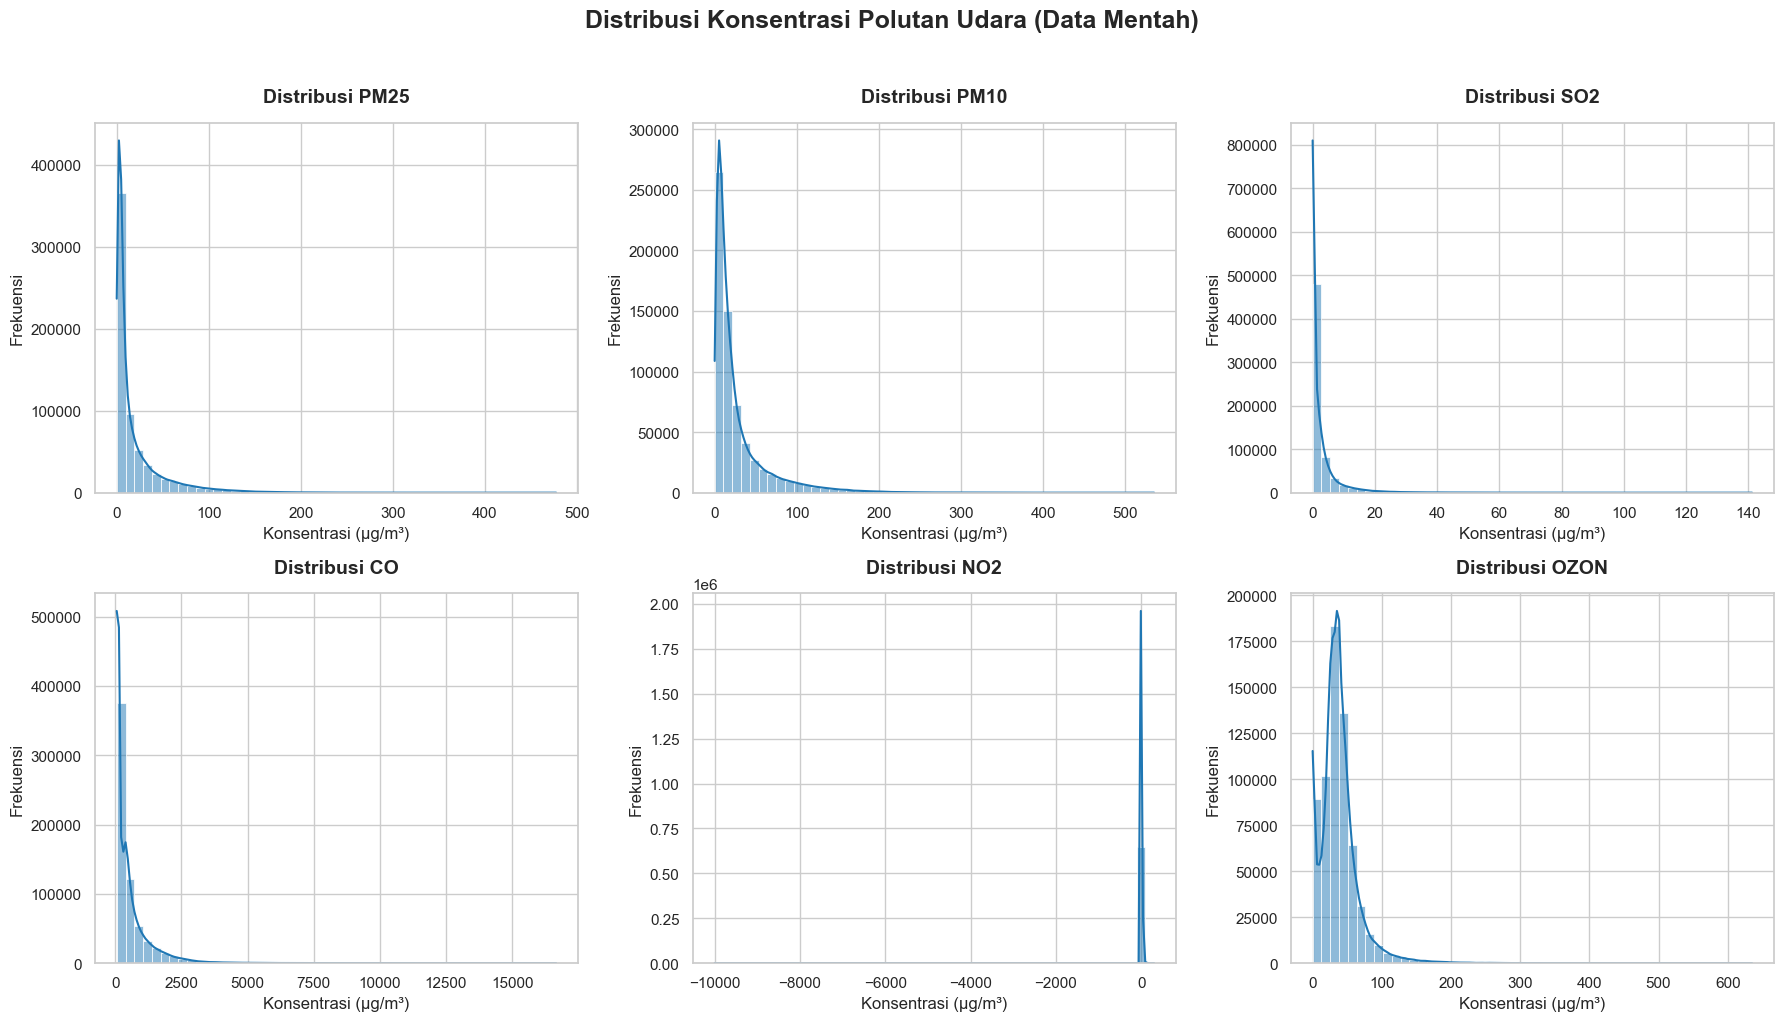

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribusi Konsentrasi Polutan Udara (Data Mentah)', 
             fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, polutan in enumerate(kolom_polutan):
    sns.histplot(df[polutan], kde=True, ax=axes[i], color='#1f77b4', bins=50)
    axes[i].set_title(f'Distribusi {polutan.upper()}', loc='center', pad=15, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Konsentrasi (µg/m³)', fontsize=12)
    axes[i].set_ylabel('Frekuensi', fontsize=12)

plt.tight_layout()
plt.show()

## Cell 7 : Deteksi Outlier dengan Boxplot

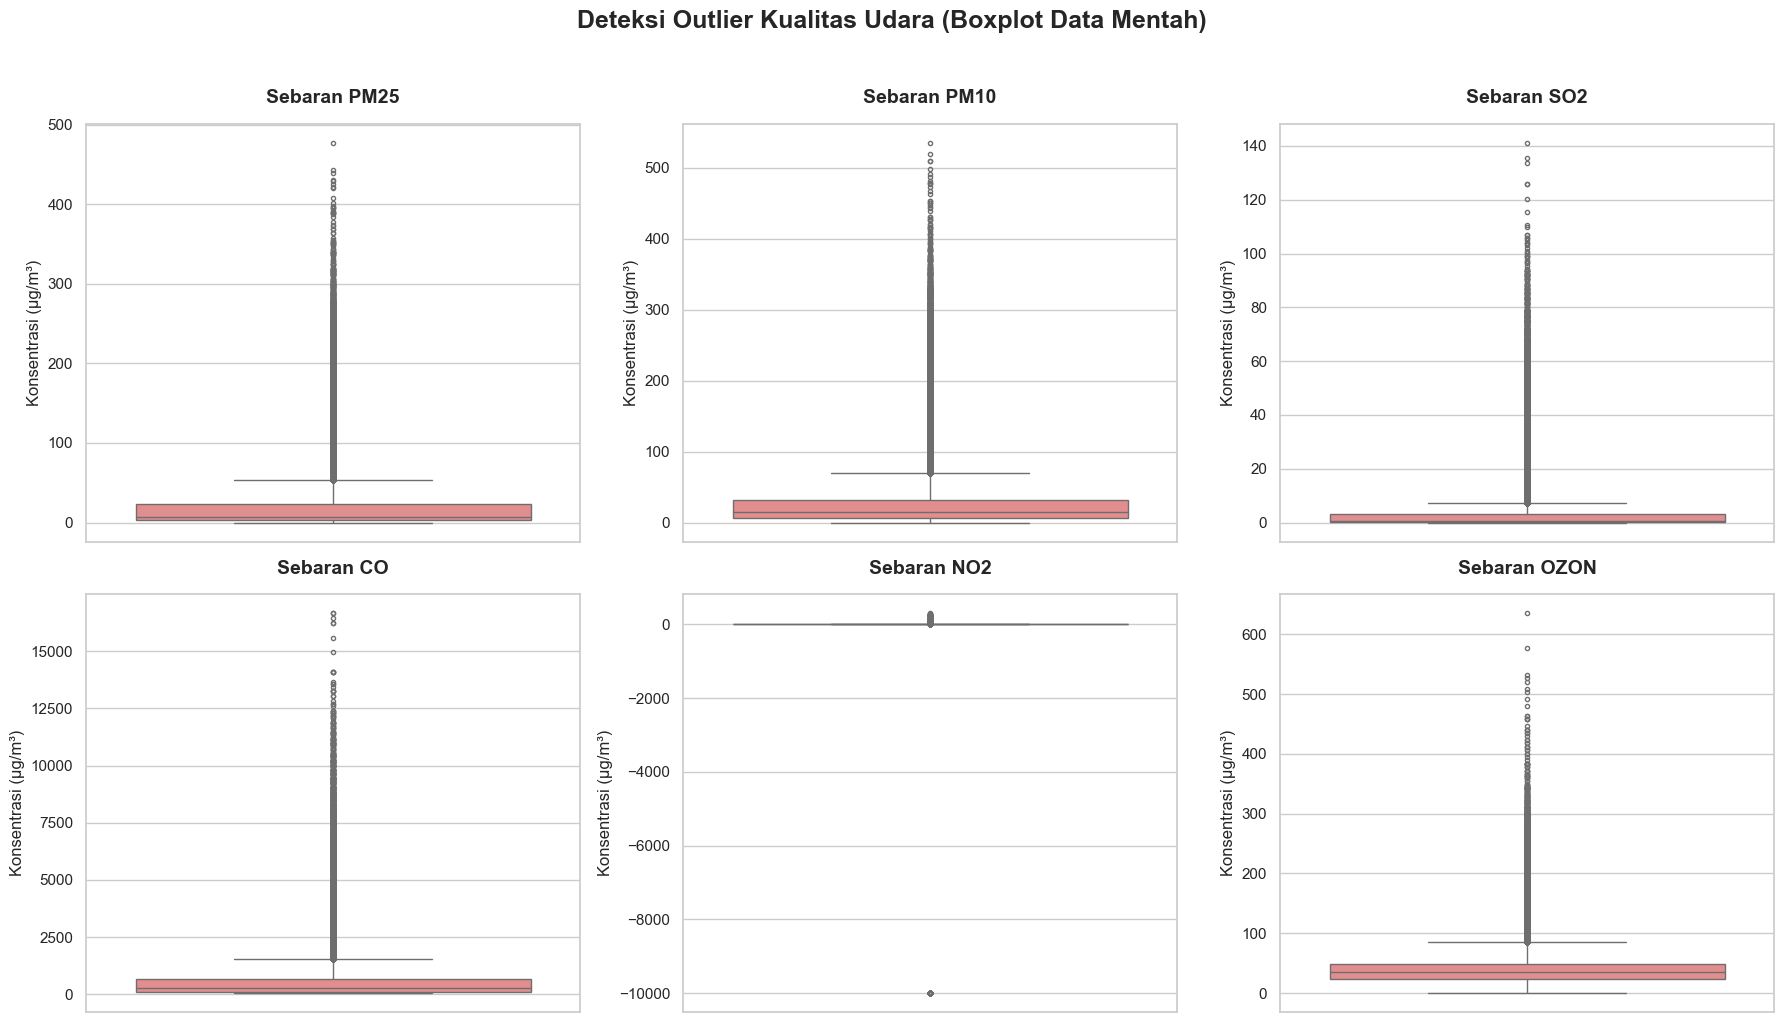

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Deteksi Outlier Kualitas Udara (Boxplot Data Mentah)', 
             fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, polutan in enumerate(kolom_polutan):
    # Menggunakan skala logaritmik jika datanya terlalu ekstrem agar outlier terlihat jelas
    sns.boxplot(y=df[polutan], ax=axes[i], color='lightcoral', fliersize=3)
    
    axes[i].set_title(f'Sebaran {polutan.upper()}', loc='center', pad=15, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Konsentrasi (µg/m³)', fontsize=12)

plt.tight_layout()
plt.show()

## Cell 8 : Korelasi Antar Polutan

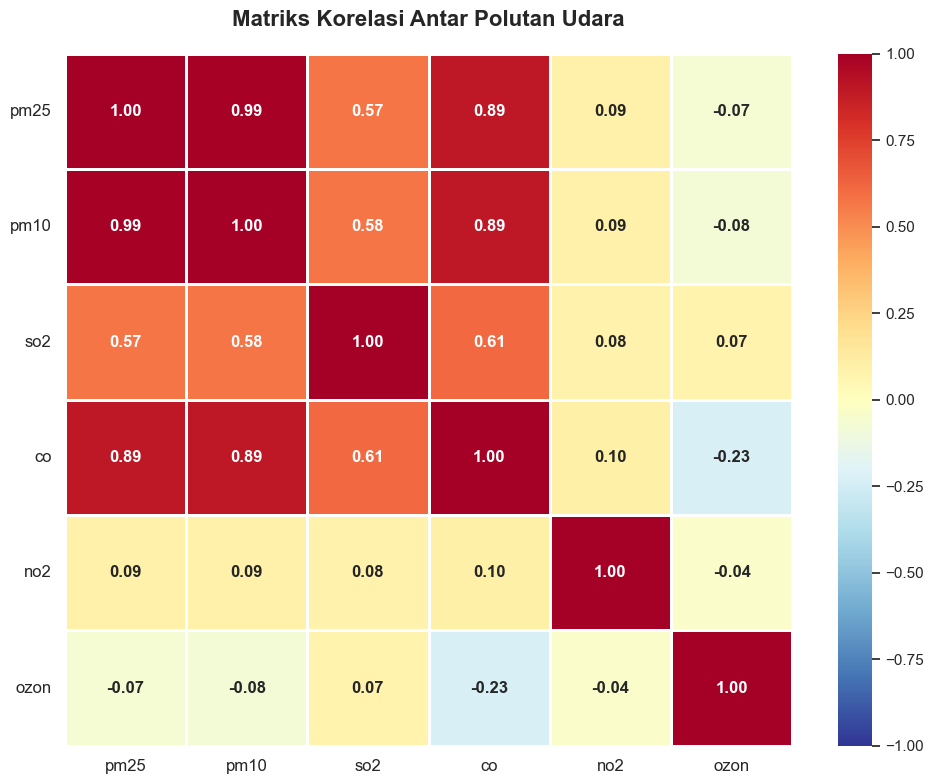

In [11]:
korelasi = df[kolom_polutan].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(korelasi, annot=True, cmap='RdYlBu_r', fmt=".2f", linewidths=1, vmin=-1, vmax=1, 
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Matriks Korelasi Antar Polutan Udara', loc='center', pad=20, fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

## Cell 9 : Eksplorasi Pola Waktu 24 Jam

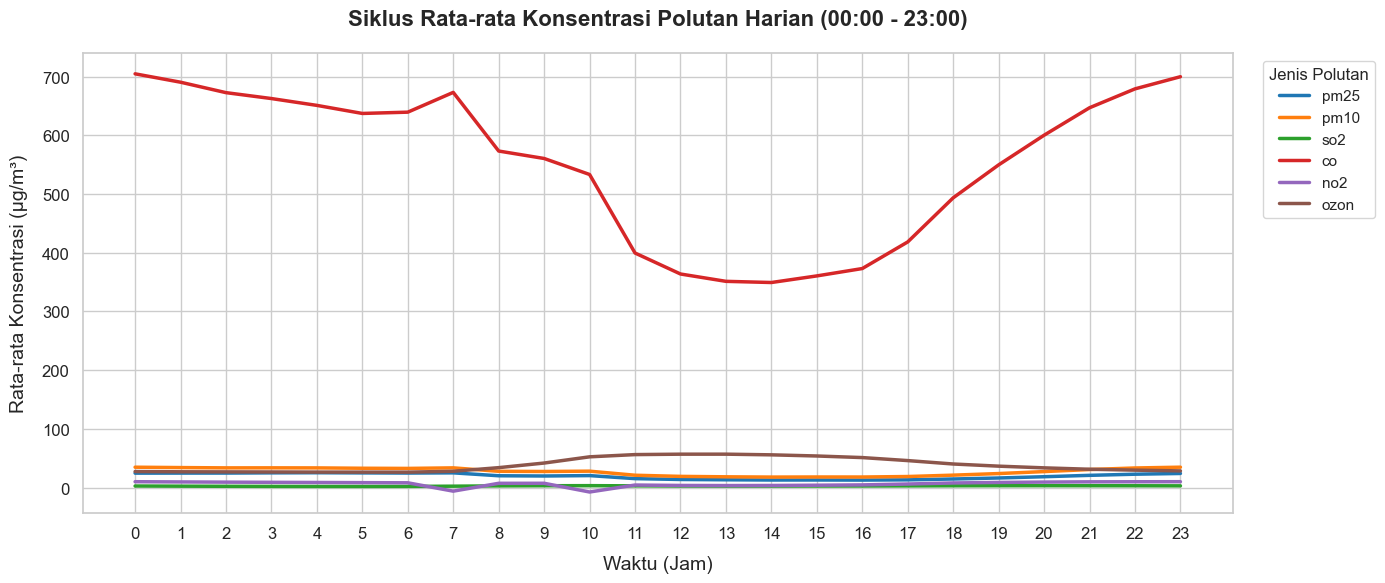

In [12]:
df['jam'] = df['waktu_aktual'].dt.hour
tren_harian = df.groupby('jam')[kolom_polutan].mean()

plt.figure(figsize=(14, 6))
sns.lineplot(data=tren_harian, dashes=False, palette='tab10', linewidth=2.5)

plt.title('Siklus Rata-rata Konsentrasi Polutan Harian (00:00 - 23:00)', loc='center', pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Waktu (Jam)', fontsize=14, labelpad=10)
plt.ylabel('Rata-rata Konsentrasi (µg/m³)', fontsize=14, labelpad=10)
plt.xticks(range(0, 24), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Jenis Polutan', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Cell 10 : Eksplorasi Wilayah

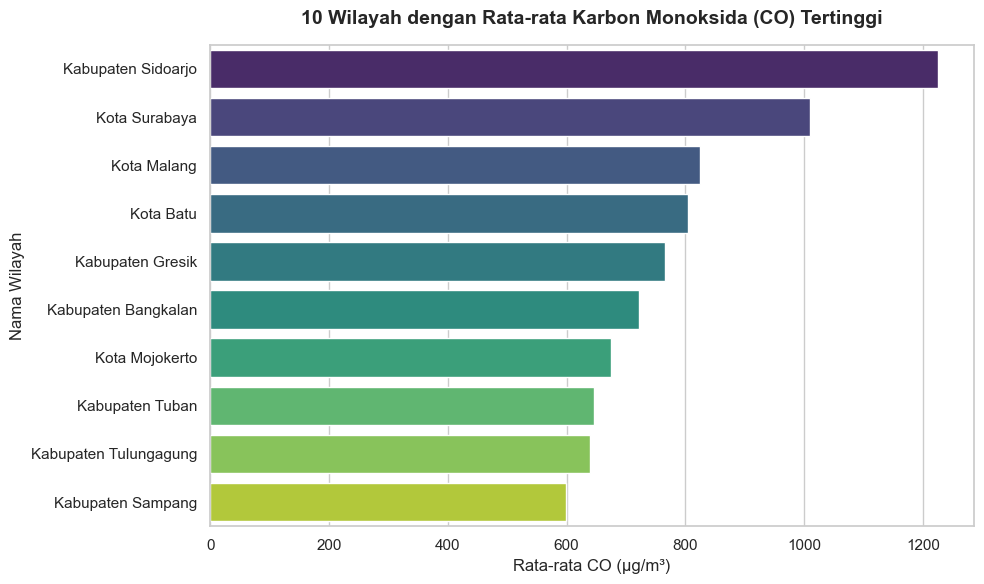

Insight: Perbedaan garis dasar (baseline) polusi antar kota ini yang mendasari penggunaan One-Hot Encoding pada id_wilayah.


In [13]:
# Menghitung rata-rata CO per kota, ambil 10 teratas
top_kota = df.groupby('nama_wilayah')['co'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_kota.values, y=top_kota.index, palette='viridis')

# Format visualisasi yang rapi
plt.title('10 Wilayah dengan Rata-rata Karbon Monoksida (CO) Tertinggi', loc='center', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata CO (µg/m³)', fontsize=12)
plt.ylabel('Nama Wilayah', fontsize=12)

plt.tight_layout()
plt.show()

print("Insight: Perbedaan garis dasar (baseline) polusi antar kota ini yang mendasari penggunaan One-Hot Encoding pada id_wilayah.")

## Cell 11 : Eksplorasi Korelasi dengan Rentang Waktu (ACF & PACF)

Pada bagian ini, kita akan melihat apakah tingkat polusi pada suatu waktu memiliki hubungan (korelasi) dengan tingkat polusi di jam-jam sebelumnya. Analisis ini bermanfaat untuk memahami apakah memori historis (deret waktu) berperan penting dalam pergerakan polutan.

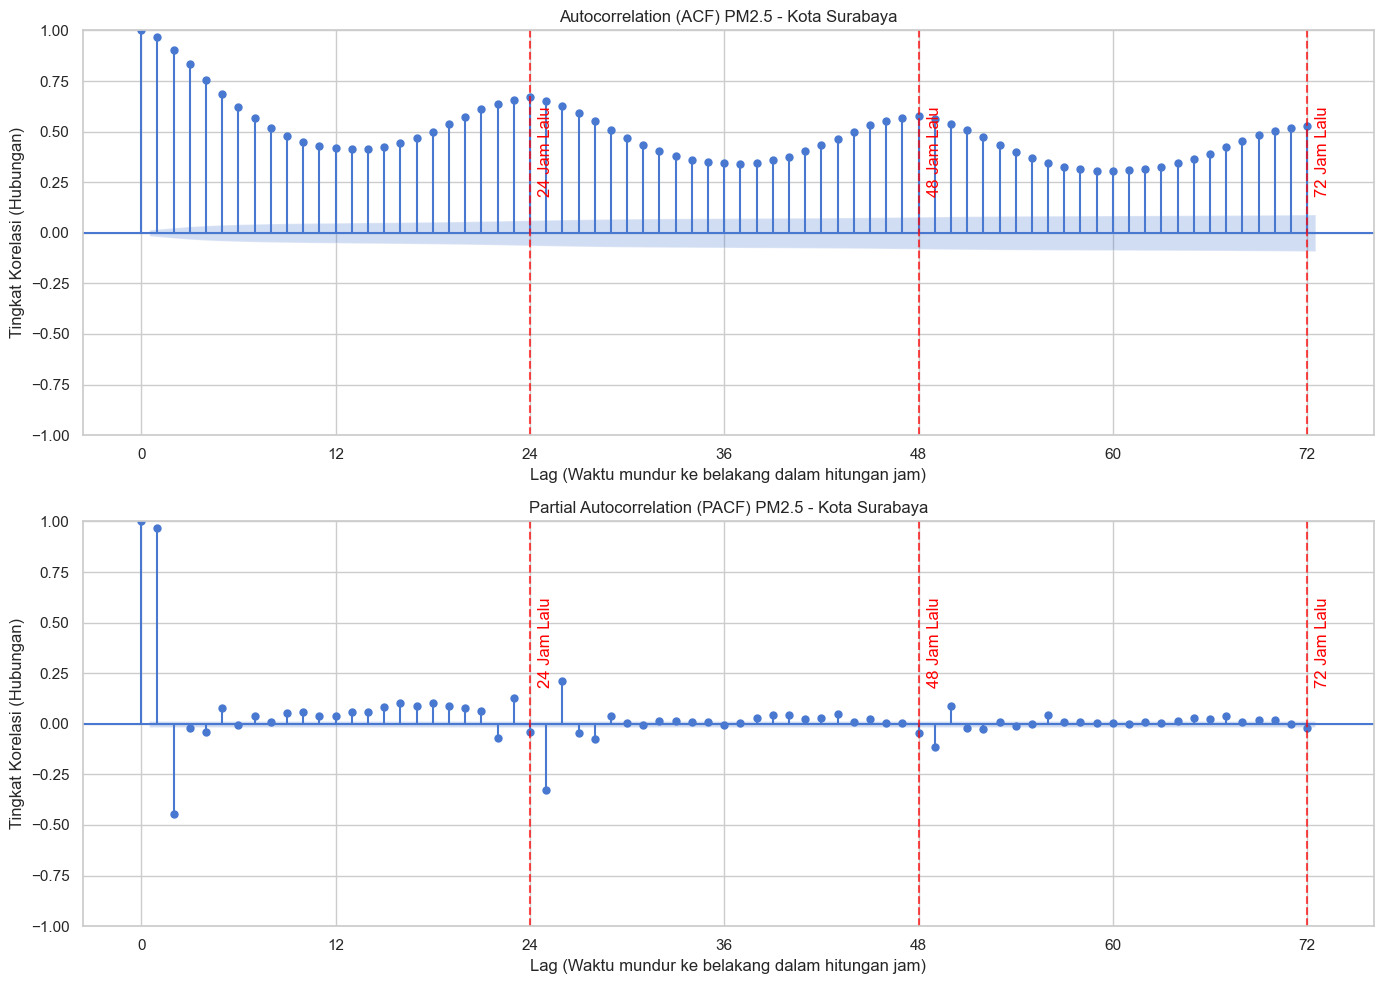


[Panduan Membaca Visualisasi]
1. Area Biru Muda: Batas kebetulan. Jika tiang berada di dalam area ini, berarti korelasi lemah atau sekadar kebetulan.
2. Garis Merah Putus-putus: Penanda waktu 1 Hari (24 Jam), 2 Hari (48 Jam), dan 3 Hari (72 Jam) yang lalu.
3. Observasi: Lihat bagaimana ujung tiang-tiang menonjol memanjang menembus area biru, TEPAT di garis merah putus-putus.
   Ini adalah BUKTI MATEMATIS bahwa pola polusi berulang setiap siklus harian, sehingga pembuatan fitur Lag-24 sangat valid!


In [17]:
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # Memastikan gaya visualisasi konsisten dengan Cell 1 (ukuran sedikit ditinggikan karena ada 2 subplot)
    plt.rcParams['figure.figsize'] = (14, 10)
    plt.rcParams['figure.dpi'] = 100
    sns.set_theme(style="whitegrid", palette="muted")
    
    # Mengambil sampel satu wilayah (misal Kota Surabaya) untuk melihat pola historis
    kota_sampel = 'Kota Surabaya'
    df_sampel = df[df['nama_wilayah'] == kota_sampel].copy()
    
    # Urutkan berdasarkan waktu dan set sebagai index
    df_sampel.set_index('waktu_aktual', inplace=True)
    df_sampel.sort_index(inplace=True)
    
    # Melihat pola per jam
    df_hourly = df_sampel['pm25'].resample('H').mean().interpolate(method='linear')
    
    fig, ax = plt.subplots(2, 1)
    
    # Mengamati autokorelasi hingga 72 jam ke belakang
    plot_acf(df_hourly.dropna(), lags=72, ax=ax[0], title=f'Autocorrelation (ACF) PM2.5 - {kota_sampel}')
    
    plot_pacf(df_hourly.dropna(), lags=72, ax=ax[1], title=f'Partial Autocorrelation (PACF) PM2.5 - {kota_sampel}')
    
    # --- MENAMBAHKAN GARIS BANTU UNTUK MEMPERMUDAH PEMBACAAN ---
    lags_penting = [24, 48, 72]
    
    for axis in ax:
        axis.set_xlabel('Lag (Waktu mundur ke belakang dalam hitungan jam)', fontsize=12)
        axis.set_ylabel('Tingkat Korelasi (Hubungan)', fontsize=12)
        axis.set_xticks(np.arange(0, 73, 12)) # Menampilkan angka di sumbu X tiap kelipatan 12 agar rapi
        
        # Menggambar garis vertikal merah penanda kelipatan 24 jam (1, 2, dan 3 hari yang lalu)
        for lag in lags_penting:
            axis.axvline(x=lag, color='red', linestyle='--', alpha=0.7)
            # Menambahkan teks penanda di dekat garis merah
            axis.text(lag + 0.5, 0.4, f'{lag} Jam Lalu', color='red', rotation=90, verticalalignment='center')
            
    plt.tight_layout()
    plt.show()
    
    print("\n[Panduan Membaca Visualisasi]")
    print("1. Area Biru Muda: Batas kebetulan. Jika tiang berada di dalam area ini, berarti korelasi lemah atau sekadar kebetulan.")
    print("2. Garis Merah Putus-putus: Penanda waktu 1 Hari (24 Jam), 2 Hari (48 Jam), dan 3 Hari (72 Jam) yang lalu.")
    print("3. Observasi: Lihat bagaimana ujung tiang-tiang menonjol memanjang menembus area biru, TEPAT di garis merah putus-putus.")
    print("   Ini adalah BUKTI MATEMATIS bahwa pola polusi berulang setiap siklus harian, sehingga pembuatan fitur Lag-24 sangat valid!")

except ImportError:
    print("Library statsmodels belum terinstall. Menggunakan pandas autocorrelation_plot...")
